inspired by https://twitter.com/n_skene/status/1643583978207625216

In [1]:
import anndata2ri
anndata2ri.activate()
%load_ext rpy2.ipython

In [2]:
%%R -o adata
library(qs)
adata = qread('/Users/ljb80/Projects/perturbvi-deseq/sce.qs') # class: SingleCellExperiment ...

R[write to console]: qs 0.25.5

/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)
/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)


In [3]:
adata = adata # stop linter from complaining
adata.X = adata.X.tocsr()
adata

AnnData object with n_obs × n_vars = 50985 × 17034
    obs: 'barcode', 'manifest', 'sample_id', 'individual', 'pathological_diagnosis', 'braak', 'cerad', 'amyloid', 'tangles', 'cogdx', 'pathological_diagnosis_original', 'group', 'apoe', 'age', 'sex', 'PMI', 'brain_region', 'is_empty_drop', 'total_counts', 'total_features_by_counts', 'pc_mito', 'pc_ribo', 'is_singlet', 'clusters', 'partitions', 'cluster_celltype', 'Allan2019_ML1', 'Allan2019_ML2', 'Zeisel2018_ML4', 'Zeisel2018_ML5', 'allan_celltype', 'allan_layer', 'allan_cluster_gene_1', 'allan_cluster_gene_2'
    var: 'ensembl_gene_id', 'gene_biotype', 'gene', 'percentage_gene_gc_content', 'total_counts', 'n_cells_by_counts'
    obsm: 'Liger', 'pca_by_individual', 'PCA_PB', 'X_pca', 'tsne_by_individual', 'tSNE_Liger', 'tSNE_PCA', 'umap_by_individual', 'UMAP_Liger', 'UMAP_PCA_PB', 'UMAP_PCA', 'UMAP3D_Liger', 'UMAP3D_PCA'

/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


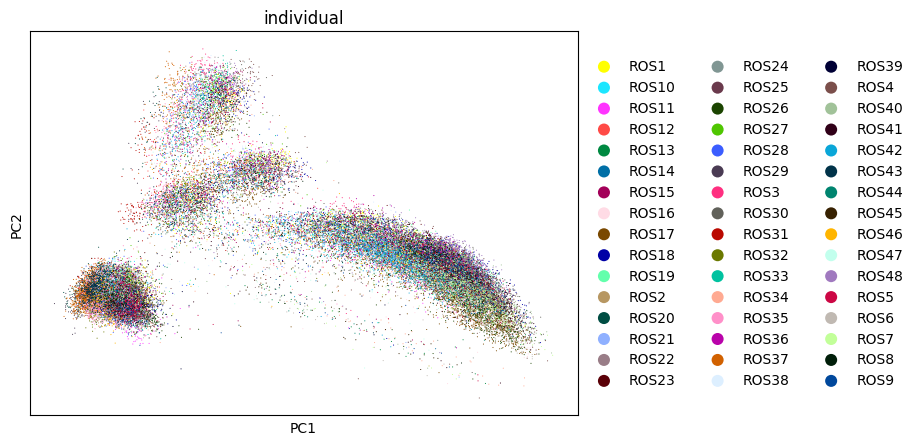

In [4]:
import perturbvi
import scanpy as sc
sc.pl.scatter(adata, color=['individual'], basis='pca')

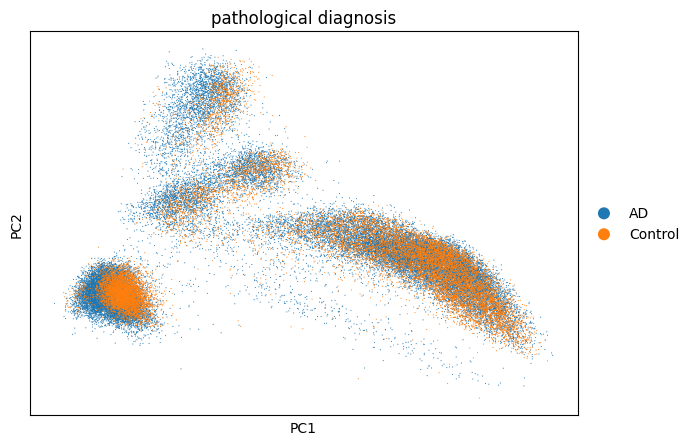

In [5]:
sc.pl.scatter(adata, color=['pathological_diagnosis'], basis='pca')

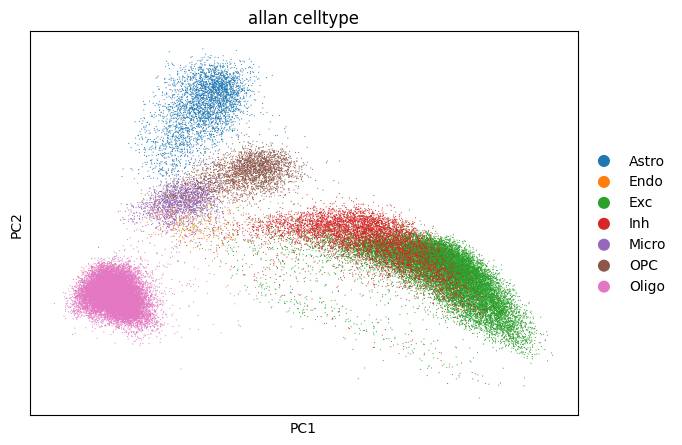

In [6]:
sc.pl.scatter(adata, color=['allan_celltype'], basis='pca')

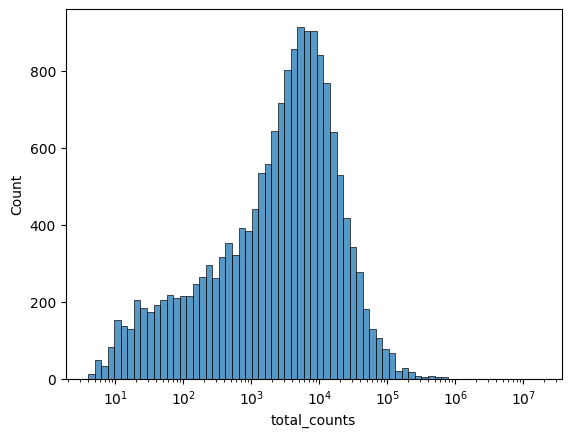

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(adata.var.total_counts.astype('int'), log_scale=[True, False])
plt.show()

In [8]:
import perturbvi
adata.obsm['disease'] = adata.obs['pathological_diagnosis'].values.reshape(-1, 1) == 'AD'
adata.obsm['disease'].mean()

0.6896342061390605

In [9]:
adata.obs.columns

Index(['barcode', 'manifest', 'sample_id', 'individual',
       'pathological_diagnosis', 'braak', 'cerad', 'amyloid', 'tangles',
       'cogdx', 'pathological_diagnosis_original', 'group', 'apoe', 'age',
       'sex', 'PMI', 'brain_region', 'is_empty_drop', 'total_counts',
       'total_features_by_counts', 'pc_mito', 'pc_ribo', 'is_singlet',
       'clusters', 'partitions', 'cluster_celltype', 'Allan2019_ML1',
       'Allan2019_ML2', 'Zeisel2018_ML4', 'Zeisel2018_ML5', 'allan_celltype',
       'allan_layer', 'allan_cluster_gene_1', 'allan_cluster_gene_2'],
      dtype='object')

In [10]:
adata.obs['sex_is_female']=adata.obs['sex']=="M"

In [11]:
%load_ext autoreload
%autoreload 2
subset_index = adata.var.query("gene=='DHFR'").index
adata_subset = adata[:, subset_index].copy()
perturbvi.PERTURBVI.setup_anndata(
    adata_subset,
    perturbation_key="disease",
    library_size_key="total_counts",
    batch_key="individual",
    categorical_covariates_keys=["sex","allan_celltype"],
    continuous_covariates_keys=['pc_mito', 'pc_ribo'],
)

INFO     Generating sequential column names                                                                        


In [12]:
model = perturbvi.PERTURBVI(adata_subset)
model.view_anndata_setup()

Anndata setup with scvi-tools version 0.20.3.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'perturbation_key': 'disease',
│   'layer': None,
│   'batch_key': 'individual',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['pc_mito', 'pc_ribo'],
│   'categorical_covariates_keys': ['sex', 'allan_celltype'],
│   'library_size_key': 'total_counts'
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  48   │
│         n_cells          │ 50985 │
│ n_extra_categorical_covs │   2   │
│ n_extra_continuous_covs  │   2   │
│     n_perturbations      │   1   │
│          n_vars          │   1   │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│ extra_continuous_covs  │ adata.obsm['_scvi_extra_continuous_covs']  │
│         ind_x          │            adata.obs['_ind_x']             │
│     perturbations      │           adata.obsm['disease']            │
│      size_factor       │         adata.obs['_size_factor']          │
└────────────────────────┴────────────────────────────────────────────┘

                     batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['individual'] │    ROS1    │          0          │
│                         │   ROS10    │          1          │
│                         │   ROS11    │          2          │
│                         │   ROS12    │          3          │
│                         │   ROS13    │          4          │
│                         │   ROS14    │          5          │
│                         │   ROS15    │          6          │
│                         │   ROS16    │          7          │
│                         │   ROS17    │          8          │
│                         │   ROS18    │          9          │
│                         │   ROS19    │         10          │
│                         │    ROS2    │         11          │
│                         │   ROS20    │         12          │
│                         │   ROS21    │         13          │
│                         │   ROS22    │         14          │
│                         │   ROS23    │         15          │
│                         │   ROS24    │         16          │
│                         │   ROS25    │         17          │
│                         │   ROS26    │         18          │
│                         │   ROS27    │         19          │
│                         │   ROS28    │         20          │
│                         │   ROS29    │         21          │
│                         │    ROS3    │         22          │
│                         │   ROS30    │         23          │
│                         │   ROS31    │         24          │
│                         │   ROS32    │         25          │
│                         │   ROS33    │         26          │
│                         │   ROS34    │         27          │
│                         │   ROS35    │         28          │
│                         │   ROS36    │         29          │
│                         │   ROS37    │         30          │
│                         │   ROS38    │         31          │
│                         │   ROS39    │         32          │
│                         │    ROS4    │         33          │
│                         │   ROS40    │         34          │
│                         │   ROS41    │         35          │
│                         │   ROS42    │         36          │
│                         │   ROS43    │         37          │
│                         │   ROS44    │         38          │
│                         │   ROS45    │         39          │
│                         │   ROS46    │         40          │
│                         │   ROS47    │         41          │
│                         │   ROS48    │         42          │
│                         │    ROS5    │         43          │
│                         │    ROS6    │         44          │
│                         │    ROS7    │         45          │
│                         │    ROS8    │         46          │
│                         │    ROS9    │         47          │
└─────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs  
     State Registry     
┏━━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location    ┃
┡━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['pc_mito'] │
│ adata.obs['pc_ribo'] │
└──────────────────────┘

              extra_categorical_covs State Registry               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location       ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['allan_celltype'] │   Astro    │          0          │
│                             │    Endo    │          1          │
│                             │    Exc     │          2          │
│                             │    Inh     │          3          │
│                             │   Micro    │          4          │
│                             │    OPC     │          5          │
│                             │   Oligo    │          6          │
│                             │            │                     │
│      adata.obs['sex']       │     F      │          0          │
│                             │     M      │          1          │
│                             │            │                     │
└─────────────────────────────┴────────────┴─────────────────────┘

In [13]:
from scvi import REGISTRY_KEYS
# model.get_from_registry(adata_subset, REGISTRY_KEYS.CAT_COVS_KEY).max()
model._validate_anndata()
model.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key

(2, 7)

In [14]:
adata_subset.obsm["_scvi_extra_categorical_covs"].max()

sex               1
allan_celltype    6
dtype: int8

In [15]:
# import numpy as np
# n_vars = 5
# n_genes = 2
# test_labels=np.zeros(100,n_vars)
# test_effects=np.zeros(n_vars, n_genes)

# test_idx = np.random.randint(np.full((100,n_vars),5))

In [20]:
model.train(50, batch_size=1024, lr=0.01)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 18/50:  34%|███▍      | 17/50 [00:09<00:18,  1.76it/s, v_num=1, elbo_train=3.37e+4]

/Users/ljb80/Projects/perturbvi/.hatch/dev/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [22]:
model

MyPyroModel Model with params:
n_batch: 48
n_cells: 50985
n_extra_categorical_covs: 2
n_extra_continuous_covs: 2
n_perturbations: 1
n_vars: 1

Training status: Trained
Model's adata is minified?: False

In [29]:
import pyro
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()

perturb_mean_lfc_mu.shape


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 9/50:  16%|█▌        | 8/50 [06:55<36:19, 51.90s/it, v_num=1, elbo_train=3.55e+4]


NameError: name 'norm' is not defined